# 02 — Graph Construction & Feature Engineering

**Project:** DDI-Graph-LLM  
**Phase 2:** Build the directed DDI graph, compute node-level and edge-level topological features, detect communities, and prepare train/test splits.

**Input:** `../data/drug_interactions_labeled.csv` (from Phase 1)  
**Output:** `../data/edge_features.csv` — one row per edge with 14 structural features + label


In [1]:
import pandas as pd
import numpy as np
import re
import time
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)


## 1. Load Labeled Data

In [2]:
# Load raw data and apply NLP labeling (from Phase 1)
df = pd.read_csv("../data/drug_interactions.csv")

PATTERNS = [
    (r"metabolism.*(?:increased|decreased)", "metabolism"),
    (r"active metabolites", "metabolism"),
    (r"serum concentration.*(?:increased|decreased|reduced)", "concentration"),
    (r"bioavailability.*(?:increased|decreased)", "concentration"),
    (r"protein binding", "concentration"),
    (r"risk or severity of adverse effects", "adverse_effects"),
    (r"risk or severity of.*(?:prolongation|bleeding|hypotension|hypertension|heart failure|hyperkalemia)", "adverse_effects"),
    (r"risk of a hypersensitivity", "adverse_effects"),
    (r"therapeutic efficacy.*(?:decreased|increased)", "efficacy"),
    (r"decrease effectiveness", "efficacy"),
    (r"decrease in the absorption", "absorption"),
    (r"absorption.*(?:increased|decreased)", "absorption"),
    (r"excretion rate", "excretion"),
    (r"(?:increase|decrease).*(?:activities|activity)", "activity"),
]

def extract_label(desc):
    desc_lower = desc.lower()
    for pattern, label in PATTERNS:
        if re.search(pattern, desc_lower):
            return label
    return None

df['label'] = df['Interaction Description'].apply(extract_label)
df_labeled = df.dropna(subset=['label'])
print(f"Labeled edges: {len(df_labeled):,}")


Labeled edges: 191,541


## 2. Build Directed Graph

Each edge `(u, v)` means drug `u` has a documented effect on drug `v`. The edge carries the NLP-extracted interaction type as a label attribute.


In [3]:
G = nx.DiGraph()
for _, row in df_labeled.iterrows():
    G.add_edge(row['Drug 1'], row['Drug 2'], label=row['label'])

print(f"Nodes: {G.number_of_nodes():,}")
print(f"Edges: {G.number_of_edges():,}")
print(f"Density: {nx.density(G):.6f}")
print(f"Weakly connected: {nx.is_weakly_connected(G)}")
print(f"Components: {nx.number_weakly_connected_components(G)}")


Nodes: 1,701
Edges: 191,252
Density: 0.066138
Weakly connected: False
Components: 2


## 3. Compute Node Features

For each drug node we compute:
- **In-degree / Out-degree** — how many drugs affect it / it affects
- **Betweenness centrality** — how often it lies on shortest paths (approximated with k=100 samples for speed)
- **Clustering coefficient** — how connected its neighbors are to each other (on undirected projection)
- **PageRank** — global importance measure


In [4]:
t0 = time.time()
in_deg = dict(G.in_degree())
out_deg = dict(G.out_degree())
print(f"Degree: {time.time()-t0:.1f}s")

t0 = time.time()
betweenness = nx.betweenness_centrality(G, k=100, seed=42)
print(f"Betweenness (approx k=100): {time.time()-t0:.1f}s")

t0 = time.time()
G_undirected = G.to_undirected()
clustering = nx.clustering(G_undirected)
print(f"Clustering: {time.time()-t0:.1f}s")

t0 = time.time()
pagerank = nx.pagerank(G)
print(f"PageRank: {time.time()-t0:.1f}s")

# Store in dict
node_features = {}
for node in G.nodes():
    node_features[node] = {
        "in_degree": in_deg[node],
        "out_degree": out_deg[node],
        "betweenness": betweenness[node],
        "clustering": clustering[node],
        "pagerank": pagerank[node],
    }

print(f"\nNode features computed for {len(node_features):,} drugs")


Degree: 0.0s
Betweenness (approx k=100): 2.4s
Clustering: 25.3s
PageRank: 0.2s

Node features computed for 1,701 drugs


## 4. Community Detection

Use Louvain algorithm on the undirected projection to assign each drug to a community. The `same_community` feature will indicate whether two drugs in an edge belong to the same community.


In [5]:
from networkx.algorithms.community import louvain_communities

t0 = time.time()
communities_list = louvain_communities(G_undirected, seed=42)

community_map = {}
for idx, community in enumerate(communities_list):
    for node in community:
        community_map[node] = idx

print(f"Detected {len(communities_list)} communities in {time.time()-t0:.1f}s")

# Community size distribution
comm_sizes = [len(c) for c in communities_list]
for i, size in enumerate(sorted(comm_sizes, reverse=True)):
    print(f"  Community {i}: {size} drugs")


Detected 8 communities in 2.3s
  Community 0: 648 drugs
  Community 1: 625 drugs
  Community 2: 383 drugs
  Community 3: 24 drugs
  Community 4: 10 drugs
  Community 5: 7 drugs
  Community 6: 2 drugs
  Community 7: 2 drugs


### 4.1 Community Size Distribution

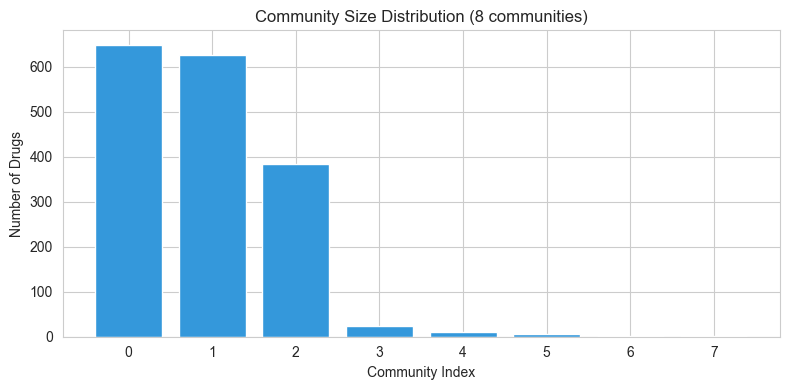

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
comm_sizes_sorted = sorted(comm_sizes, reverse=True)
ax.bar(range(len(comm_sizes_sorted)), comm_sizes_sorted, color='#3498db')
ax.set_xlabel('Community Index')
ax.set_ylabel('Number of Drugs')
ax.set_title(f'Community Size Distribution ({len(communities_list)} communities)')
plt.tight_layout()
plt.show()


## 5. Compute Edge Features

For each edge `(u, v)` we compute a 14-dimensional feature vector:

| Feature | Description |
|---------|-------------|
| `out_degree_u` | Out-degree of source drug |
| `in_degree_u` | In-degree of source drug |
| `betweenness_u` | Betweenness centrality of source drug |
| `clustering_u` | Clustering coefficient of source drug |
| `pagerank_u` | PageRank of source drug |
| `out_degree_v` | Out-degree of target drug |
| `in_degree_v` | In-degree of target drug |
| `betweenness_v` | Betweenness centrality of target drug |
| `clustering_v` | Clustering coefficient of target drug |
| `pagerank_v` | PageRank of target drug |
| `common_neighbors` | Number of shared neighbors (undirected) |
| `jaccard` | Jaccard coefficient (undirected) |
| `same_community` | 1 if same Louvain community, else 0 |
| `degree_diff` | Absolute difference in total degree |


In [7]:
t0 = time.time()

# Precompute neighbor sets for speed
neighbor_sets = {node: set(G_undirected.neighbors(node)) for node in G_undirected.nodes()}

records = []
for i, (u, v, data) in enumerate(G.edges(data=True)):
    nf_u = node_features[u]
    nf_v = node_features[v]
    
    # Common neighbors (undirected)
    cn = len(neighbor_sets[u] & neighbor_sets[v])
    
    # Jaccard coefficient
    union_size = len(neighbor_sets[u] | neighbor_sets[v])
    jc = cn / union_size if union_size > 0 else 0.0
    
    # Same community
    sc = int(community_map.get(u, -1) == community_map.get(v, -2))
    
    records.append({
        "drug_u": u,
        "drug_v": v,
        "label": data.get("label"),
        "out_degree_u": nf_u["out_degree"],
        "in_degree_u": nf_u["in_degree"],
        "betweenness_u": nf_u["betweenness"],
        "clustering_u": nf_u["clustering"],
        "pagerank_u": nf_u["pagerank"],
        "out_degree_v": nf_v["out_degree"],
        "in_degree_v": nf_v["in_degree"],
        "betweenness_v": nf_v["betweenness"],
        "clustering_v": nf_v["clustering"],
        "pagerank_v": nf_v["pagerank"],
        "common_neighbors": cn,
        "jaccard": jc,
        "same_community": sc,
        "degree_diff": abs(
            (nf_u["in_degree"] + nf_u["out_degree"]) -
            (nf_v["in_degree"] + nf_v["out_degree"])
        ),
    })
    
    if (i + 1) % 50000 == 0:
        print(f"  Processed {i+1:,} / {G.number_of_edges():,} edges...")

df_features = pd.DataFrame(records)
print(f"\nDone: {len(df_features):,} rows, {len(df_features.columns)} columns in {time.time()-t0:.1f}s")
df_features.head()


  Processed 50,000 / 191,252 edges...
  Processed 100,000 / 191,252 edges...
  Processed 150,000 / 191,252 edges...

Done: 191,252 rows, 17 columns in 12.9s


,drug_u,drug_v,label,out_degree_u,in_degree_u,betweenness_u,clustering_u,pagerank_u,out_degree_v,in_degree_v,betweenness_v,clustering_v,pagerank_v,common_neighbors,jaccard,same_community,degree_diff
0,Trioxsalen,Verteporfin,activity,1,0,0.0,0.000000,0.000099,5,15,0.000000,0.247368,0.000692,0,0.000000,1,19
1,Verteporfin,Digoxin,activity,5,15,0.0,0.247368,0.000692,257,275,0.012747,0.275828,0.002828,8,0.014760,1,512
2,Verteporfin,Digitoxin,activity,5,15,0.0,0.247368,0.000692,97,290,0.003638,0.239185,0.002835,6,0.014963,1,367
3,Verteporfin,Deslanoside,activity,5,15,0.0,0.247368,0.000692,47,284,0.002450,0.161421,0.003068,6,0.017391,1,311
4,Verteporfin,Acetyldigitoxin,activity,5,15,0.0,0.247368,0.000692,47,284,0.002450,0.161421,0.003068,6,0.017391,1,311


### 5.1 Feature Statistics

In [8]:
FEATURE_COLS = [
    "out_degree_u", "in_degree_u", "betweenness_u", "clustering_u", "pagerank_u",
    "out_degree_v", "in_degree_v", "betweenness_v", "clustering_v", "pagerank_v",
    "common_neighbors", "jaccard", "same_community", "degree_diff",
]

df_features[FEATURE_COLS].describe().round(4)


,out_degree_u,in_degree_u,betweenness_u,clustering_u,pagerank_u,out_degree_v,in_degree_v,betweenness_v,clustering_v,pagerank_v,common_neighbors,jaccard,same_community,degree_diff
count,191252.0000,191252.0000,191252.0000,191252.0000,191252.0000,191252.0000,191252.0000,191252.0000,191252.0000,191252.0000,191252.0000,191252.0000,191252.0000,191252.0000
mean,233.1688,149.5424,0.0016,0.5482,0.0007,149.5424,257.5927,0.0016,0.5280,0.0012,195.0485,0.3378,0.6351,226.9513
std,156.0274,120.6821,0.0029,0.1779,0.0006,106.6006,173.5401,0.0028,0.1830,0.0009,117.1202,0.2091,0.4814,173.9120
min,1.0000,0.0000,0.0000,0.0000,0.0001,0.0000,1.0000,0.0000,0.0000,0.0001,0.0000,0.0000,0.0000,0.0000
25%,121.0000,60.0000,0.0001,0.4168,0.0003,71.0000,130.0000,0.0002,0.3905,0.0006,105.0000,0.1879,0.0000,86.0000
50%,196.0000,130.0000,0.0005,0.5217,0.0006,132.0000,207.0000,0.0006,0.4869,0.0009,181.0000,0.2936,1.0000,188.0000
75%,303.0000,196.0000,0.0016,0.6491,0.0009,202.0000,340.0000,0.0020,0.6161,0.0017,272.0000,0.4555,1.0000,334.0000
max,850.0000,736.0000,0.0290,1.0000,0.0056,850.0000,736.0000,0.0290,1.0000,0.0061,886.0000,0.9961,1.0000,905.0000


### 5.2 Feature Correlation Heatmap

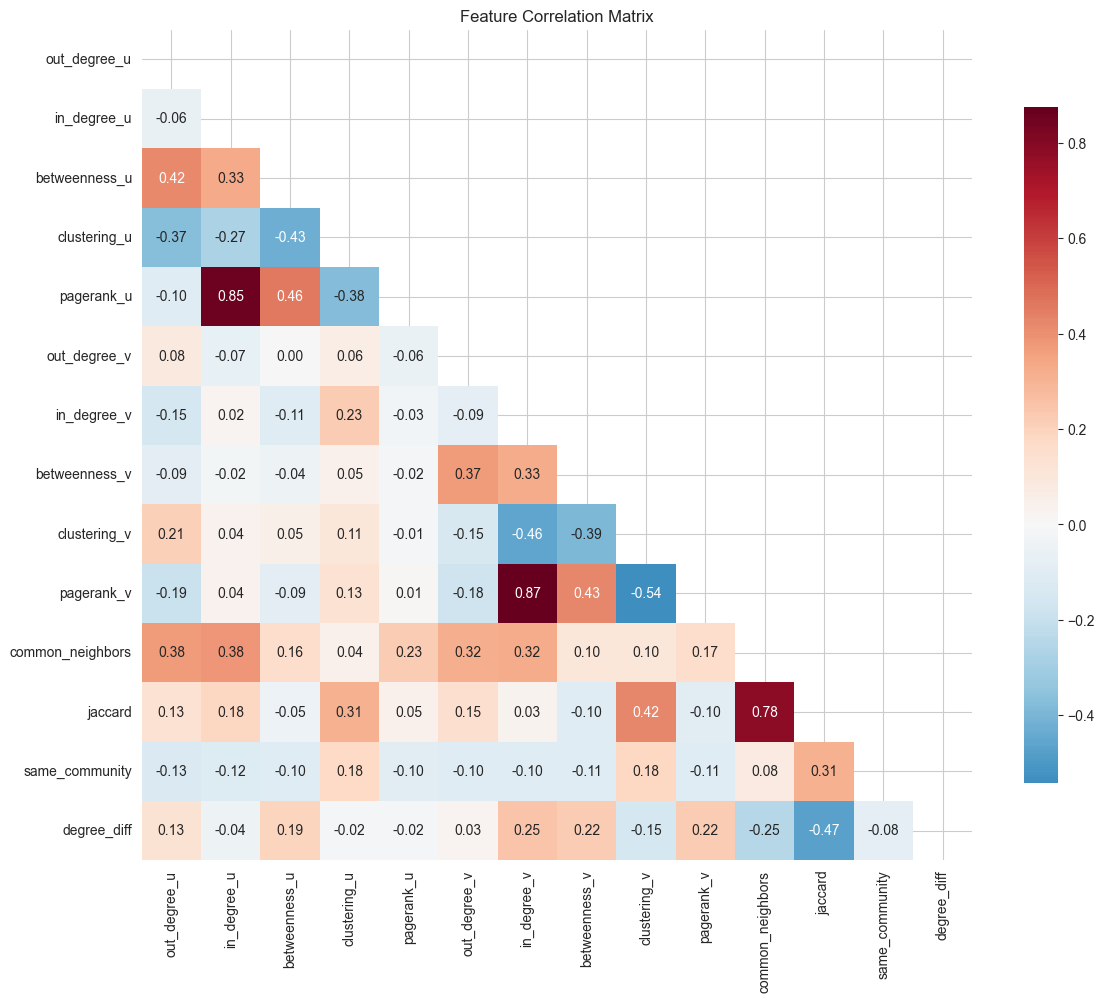

In [9]:
fig, ax = plt.subplots(figsize=(12, 10))
corr = df_features[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


### 5.3 Key Features by Interaction Type

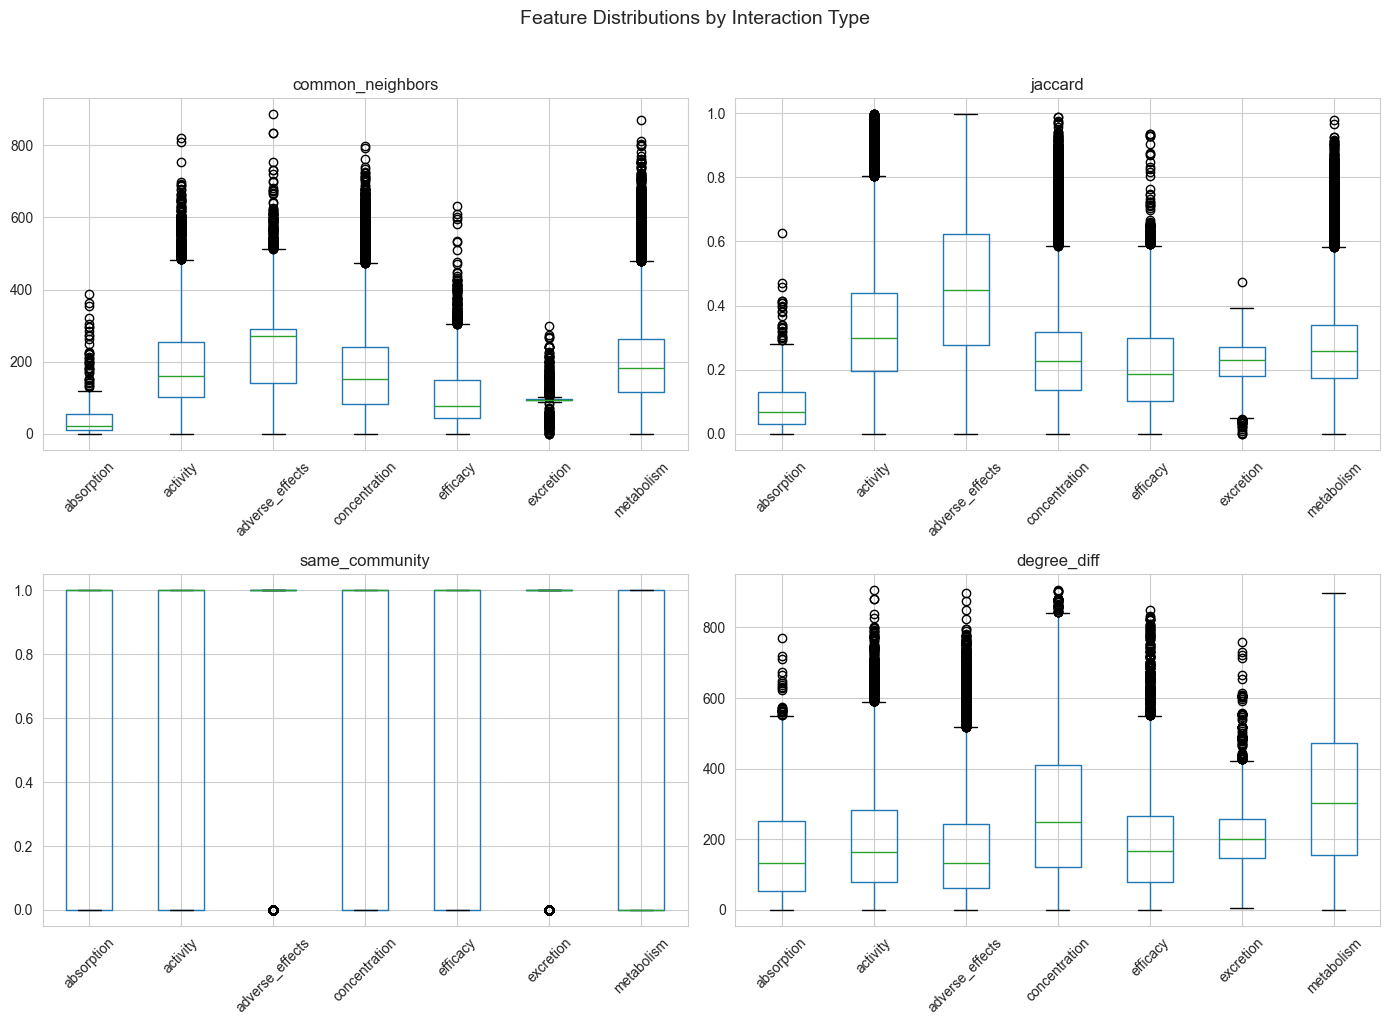

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feat in zip(axes.flat, ['common_neighbors', 'jaccard', 'same_community', 'degree_diff']):
    df_features.boxplot(column=feat, by='label', ax=ax, rot=45)
    ax.set_title(feat)
    ax.set_xlabel('')

plt.suptitle('Feature Distributions by Interaction Type', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


## 6. Train / Test Split

80/20 stratified split to preserve label proportions in both sets.


In [11]:
X = df_features[FEATURE_COLS].values
y = df_features["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,}  Test: {len(X_test):,}")

print(f"\nTrain label distribution:")
for label, count in Counter(y_train).most_common():
    pct = count / len(y_train) * 100
    print(f"  {label:>16s}: {count:>6,} ({pct:.1f}%)")

print(f"\nTest label distribution:")
for label, count in Counter(y_test).most_common():
    pct = count / len(y_test) * 100
    print(f"  {label:>16s}: {count:>6,} ({pct:.1f}%)")


Train: 153,001  Test: 38,251

Train label distribution:
   adverse_effects: 49,108 (32.1%)
          activity: 36,251 (23.7%)
        metabolism: 31,943 (20.9%)
     concentration: 26,961 (17.6%)
          efficacy:  6,441 (4.2%)
         excretion:  1,481 (1.0%)
        absorption:    816 (0.5%)

Test label distribution:
   adverse_effects: 12,278 (32.1%)
          activity:  9,063 (23.7%)
        metabolism:  7,986 (20.9%)
     concentration:  6,740 (17.6%)
          efficacy:  1,610 (4.2%)
         excretion:    370 (1.0%)
        absorption:    204 (0.5%)


In [12]:
# Add split column to the features dataframe for downstream use
df_features['split'] = 'train'
test_indices = train_test_split(
    df_features.index, test_size=0.2, random_state=42, 
    stratify=df_features['label']
)[1]
df_features.loc[test_indices, 'split'] = 'test'

print(f"Train edges: {(df_features['split']=='train').sum():,}")
print(f"Test edges:  {(df_features['split']=='test').sum():,}")


Train edges: 153,001
Test edges:  38,251


## 7. Save Processed Data

In [13]:
df_features.to_csv("../data/edge_features.csv", index=False)
print(f"Saved edge_features.csv: {len(df_features):,} rows x {len(df_features.columns)} columns")
print(f"Columns: {list(df_features.columns)}")


Saved edge_features.csv: 191,252 rows x 18 columns
Columns: ['drug_u', 'drug_v', 'label', 'out_degree_u', 'in_degree_u', 'betweenness_u', 'clustering_u', 'pagerank_u', 'out_degree_v', 'in_degree_v', 'betweenness_v', 'clustering_v', 'pagerank_v', 'common_neighbors', 'jaccard', 'same_community', 'degree_diff', 'split']


## Summary

**Phase 2 complete.** Key outputs:

| Metric | Value |
|--------|-------|
| Graph nodes (drugs) | 1,701 |
| Graph edges (interactions) | 191,252 |
| Communities detected | 8 |
| Edge features computed | 14 |
| Train set size | 153,001 (80%) |
| Test set size | 38,251 (20%) |

**Feature columns (14):**
`out_degree_u`, `in_degree_u`, `betweenness_u`, `clustering_u`, `pagerank_u`,
`out_degree_v`, `in_degree_v`, `betweenness_v`, `clustering_v`, `pagerank_v`,
`common_neighbors`, `jaccard`, `same_community`, `degree_diff`

**Saved:** `../data/edge_features.csv` (with `drug_u`, `drug_v`, `label`, 14 features, `split` column)

**Next:** Phase 3 — Condition B1 (Random Forest baseline) in `03_baseline_rf.ipynb`
